# Single-Frame Magnitude Limit Comparison

_Author_: Alex Drlica-Wagner (@kadrlica)</br>
_Date_: 2026-02-14

This notebook is intended to perform comparisons between the single-frame point-source magnitude limit estimated by ExposureSummaryStats (`stats_mag_lim`) and the same quantity estimated directly from the catalogs. In addition, it hopefully provides some context on data discovery within the current state of DM processing.

In [1]:
# Common imports
import os

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import astropy.io.fits as pf
from astropy.time import Time, TimeDelta
import astropy.units as u
import scipy.stats
from scipy.spatial import cKDTree

# LSST Science Pipelines (Stack) packages                                            
import lsst.daf.butler as dafButler
import lsst.afw.display as afwDisplay

os.environ["no_proxy"] += ",.consdb"
afwDisplay.setDefaultBackend('matplotlib')

### Utility functions

Don't worry too much about these. They are copy/pasted from my personal libraries.

In [2]:
# DES color-blind friendly colors for bands
# https://github.com/DarkEnergySurvey/descolors
BAND_COLORS = dict([
    ('u','#56b4e9'),
    ('g','#008060'),
    ('r','#ff4000'),
    ('i','#850000'),
    ('z','#6600cc'),
    ('y','#000000'),
])

In [3]:
def flux2mag(flux, fluxerr):
    # Convert from nJy to AB mag
    with np.errstate(invalid='ignore'):
        nJytoAB = (1*u.nJy).to(u.ABmag).value
        mag = -2.5*np.log10(flux) + nJytoAB
        magerr = 2.5/np.log(10) * fluxerr / flux
        
    return mag, magerr

In [4]:
def ang2vec(lon, lat):
    """Convert longitude and latitude into array of unit vectors.

    Parameters
    ----------
    lon : longitude (deg)
    lat : latitude (deg)

    Returns
    -------
    vec : 2D array of vectors
    """
    lonr = np.deg2rad(lon)
    latr = np.deg2rad(lat)
    coslat = np.cos(latr)
    return np.stack([
        np.atleast_1d(np.cos(lonr) * coslat),
        np.atleast_1d(np.sin(lonr) * coslat),
        np.atleast_1d(np.sin(latr)),
    ], axis=-1)


In [5]:
def angsep(lon1,lat1,lon2,lat2):
    """
    Angular separation (deg) between two sky coordinates.
    Borrowed from astropy (www.astropy.org)

    Notes
    -----
    The angular separation is calculated using the Vincenty formula [1],
    which is slighly more complex and computationally expensive than
    some alternatives, but is stable at at all distances, including the
    poles and antipodes.

    [1] http://en.wikipedia.org/wiki/Great-circle_distance
    """
    lon1,lat1 = np.radians([lon1,lat1])
    lon2,lat2 = np.radians([lon2,lat2])
    
    sdlon = np.sin(lon2 - lon1)
    cdlon = np.cos(lon2 - lon1)
    slat1 = np.sin(lat1)
    slat2 = np.sin(lat2)
    clat1 = np.cos(lat1)
    clat2 = np.cos(lat2)

    num1 = clat2 * sdlon
    num2 = clat1 * slat2 - slat1 * clat2 * cdlon
    denominator = slat1 * slat2 + clat1 * clat2 * cdlon

    return np.degrees(np.arctan2(np.hypot(num1,num2), denominator))

In [6]:
def match_coords(lon1, lat1, lon2, lat2, tol=None, nnearest=1):
    """
    Adapted from Eric Tollerud.
    Finds matches in one catalog to another.
 
    Parameters
    lon1 : array-like
        Longitude of the first catalog (degrees)
    lat1 : array-like
        Latitude of the first catalog (shape of array must match `lon1`)
    lon2 : array-like
        Longitude of the second catalog
    lat2 : array-like
        Latitude of the second catalog (shape of array must match `lon2`)
    tol : float or None, optional
        Proximity (degrees) of a match to count as a match.  If None,
        all nearest neighbors for the first catalog will be returned.
    nnearest : int, optional
        The nth neighbor to find.  E.g., 1 for the nearest nearby, 2 for the
        second nearest neighbor, etc.  Particularly useful if you want to get
        the nearest *non-self* neighbor of a catalog.  To do this, use:
        ``spherematch(lon, lat, lon, lat, nnearest=2)``
 
    Returns
    -------
    idx1 : int array
        Indices into the first catalog of the matches. Will never be
        larger than `lon1`/`lat1`.
    idx2 : int array
        Indices into the second catalog of the matches. Will never be
        larger than `lon2`/`lat2`.
    ds : float array
        Distance (in degrees) between the matches
    """
    from scipy.spatial import cKDTree
 
    lon1 = np.asarray(lon1)
    lat1 = np.asarray(lat1)
    lon2 = np.asarray(lon2)
    lat2 = np.asarray(lat2)
 
    if lon1.shape != lat1.shape:
        raise ValueError('lon1 and lat1 do not match!')
    if lon2.shape != lat2.shape:
        raise ValueError('lon2 and lat2 do not match!')

    coords1 = ang2vec(lon1, lat1)
    coords2 = ang2vec(lon2, lat2)
 
    tree = cKDTree(coords2)
    if nnearest == 1:
        idxs2 = tree.query(coords1)[1]
    elif nnearest > 1:
        idxs2 = tree.query(coords1, nnearest)[1][:, -1]
    else:
        raise ValueError('invalid nnearest ' + str(nnearest))
 
    ds = angsep(lon1, lat1, lon2[idxs2], lat2[idxs2])
 
    idxs1 = np.arange(lon1.size)
 
    if tol is not None:
        msk = ds < tol
        idxs1 = idxs1[msk]
        idxs2 = idxs2[msk]
        ds = ds[msk]
 
    return idxs1, idxs2, ds

In [7]:
def calculate_depth_simple(flux, fluxErr, snr=10.0, epsilon=0.25):
    """Very simple depth calucation from:
    snr - epsilon <= flux/fluxErr <= snr + epsilon

    https://github.com/lsst/analysis_tools/blob/main/python/lsst/analysis/tools/atools/limitingMagnitudeMetric.py

    Parameters
    ----------
    flux, fluxErr : flux and flux error
    snr : desired signal-to-noise
    epsilon : difference in SNR

    Returns
    -------
    maglim : median magnitude limit
    """
    sel  = snr - epsilon < flux/fluxErr
    sel &= flux/fluxErr < snr + epsilon
    maglim = np.median(flux2mag(flux)[sel])
    return maglim

In [8]:
def calculate_depth(ra, dec, mag, magerr, snr=10.0):
    """This calculates the depth by performing a linear fit on the magnitude and magnitude error. 
    By doing a linear fit, you can extrapolate from the observed data to an arbritrary SNR. 
    The code is a bit more complicated than necessary, because it can be modified to calculate
    spatially-dependent magnitude limits.

    Parameters
    ----------
    ra, dec : catalog coordinates
    mag, magerr : magnitude and error
    snr : desired signal-to-noise

    Returns
    -------
    maglim : median magnitude limit
    """
    mag_snr = (2.5/np.log(10)) / (snr)

    mag_bright, mag_faint = np.nanpercentile(mag, [1,95])
   
    cut = (mag > mag_bright) & (mag < mag_faint)

    if cut.sum() < 2:
        msg = "Insufficent objects"
        raise Exception(msg)

    ra = ra[cut]
    dec = dec[cut]
    mag = mag[cut]
    magerr = magerr[cut]

    match = match_coords(ra, dec, ra, dec, nnearest=2)

    delta_mag = mag[match[1]] - mag[match[0]]
    delta_log_magerr = np.log10(magerr[match[1]]) - np.log10(magerr[match[0]])

    with np.errstate(divide='ignore', invalid='ignore'):
        ratio = delta_log_magerr / delta_mag
        cut_nan_inf = np.isfinite(ratio) & (delta_mag > 0.5)

    if cut_nan_inf.sum() < 2:
        print("WARNING: Insufficent objects.")
        return np.nan

    kde = scipy.stats.gaussian_kde(ratio[cut_nan_inf])

    values = np.linspace(0., 1., 1000)
    kde_values = kde.evaluate(values)
    slope = values[np.argmax(kde_values)]

    maglims = mag - ((np.log10(magerr) - np.log10(mag_snr)) / slope)

    return np.median(maglims)

### Find the Data

At the outset I have no idea what data exists. The processes of data discovery involves:
1. Finding the exposures that have been taken
2. Finding the collections where they have been processed
3. Finding the dataset_type of the single-frame catalogs

First we got to ConsDB to figure out what data exists. The first step is to inspect the ConsDB schema and tables.
https://sdm-schemas.lsst.io/cdb_lsstcam.html

In [9]:
from lsst.summit.utils import ConsDbClient
from lsst.summit.utils.utils import computeCcdExposureId

client = ConsDbClient('http://consdb-pq.consdb:8080/consdb')
#schema = 'lsstcomcam'
schema = 'lsstcam'
table = 'ccdvisit1_quicklook'
table = 'visit1_quicklook'
table = 'ccdexposure'
table = 'exposure'
print(f'schemas:\n', client.schema())  # list the instruments
print(f'tables (schema={schema}):\n', client.schema(schema))  # list tables for an instrument
print(f'columns (table={table}): {table}\n', sorted(list(client.schema(schema, f'cdb_{schema}.{table}').keys())))

schemas:
 ['latiss', 'lsstcam', 'lsstcamsim', 'lsstcomcam', 'lsstcomcamsim', 'startrackerfast', 'startrackernarrow', 'startrackerwide']
tables (schema=lsstcam):
 ['cdb_lsstcam.visit1_quicklook', 'cdb_lsstcam.exposure', 'cdb_lsstcam.ccdexposure', 'cdb_lsstcam.ccdexposure_camera', 'cdb_lsstcam.ccdexposure_flexdata', 'cdb_lsstcam.ccdexposure_flexdata_schema', 'cdb_lsstcam.ccdexposure_quicklook', 'cdb_lsstcam.ccdvisit1_quicklook', 'cdb_lsstcam.exposure_flexdata', 'cdb_lsstcam.exposure_flexdata_schema', 'cdb_lsstcam.exposure_quicklook', 'cdb_lsstcam.visit1', 'cdb_lsstcam.ccdvisit1']
columns (table=exposure): exposure
 ['air_temp', 'airmass', 'altitude', 'altitude_end', 'altitude_start', 'azimuth', 'azimuth_end', 'azimuth_start', 'band', 'can_see_sky', 'controller', 'cur_index', 'dark_time', 'day_obs', 'dimm_seeing', 'emulated', 'exp_midpt', 'exp_midpt_mjd', 'exp_time', 'exposure_id', 'exposure_name', 'focus_z', 'group_id', 'humidity', 'img_type', 'max_index', 'obs_end', 'obs_end_mjd', 'obs_

In [10]:
# After investigation, specify some date ranges
DAY_OBS_MIN, DAY_OBS_MAX = 20250901, 20251001
DETECTOR = 94

In [11]:
# Step 1: Query ConsDB for the list of visits, detectors

from lsst.summit.utils import ConsDbClient
from lsst.summit.utils.utils import computeCcdExposureId

client = ConsDbClient('http://consdb-pq.consdb:8080/consdb')

query = f"""
select q2e.exposure_id as visit, q2e.detector, e.band, e.exp_midpt_mjd, stats_mag_lim
from cdb_lsstcam.ccdvisit1_quicklook q,
cdb_lsstcam.ccdexposure q2e,
cdb_lsstcam.exposure e
where q2e.ccdexposure_id = q.ccdvisit_id
and q2e.exposure_id = e.exposure_id
and q2e.detector = {DETECTOR}
and q2e.day_obs between {DAY_OBS_MIN} and {DAY_OBS_MAX}
order by visit
"""

tab = client.query(query)
print(tab)

    visit     detector band   exp_midpt_mjd      stats_mag_lim   
------------- -------- ---- ------------------ ------------------
2025090200006       94    r  60921.06992503645               None
2025090200007       94    r  60921.07136011149 22.923059463500977
2025090200008       94    r  60921.07178004935  23.03091049194336
2025090200009       94    r 60921.072377304146 23.229028701782227
2025090200010       94    r 60921.072797161396  23.19965934753418
2025090200011       94    r   60921.0733680521 23.154773712158203
2025090200012       94    r    60921.073788468 22.971628189086914
2025090200013       94    r   60921.0743515741 23.014225006103516
2025090200014       94    r 60921.074771930435 23.043272018432617
2025090200015       94    r  60921.07534391801 23.101377487182617
          ...      ...  ...                ...                ...
2025092100400       94    i 60940.366357044346               None
2025092100401       94    i 60940.367103915174               None
2025092100

### Step 2: Find Repo and Collection 

I'm not sure if there is a way to discover repos from the butler. What I usually do is go to the human-readable summaries in Campaign Management ([ls.st/campaigns](https://ls.st/campaigns)) to find the list of repos and collections. Of course there are ways to query collections once you have the repo, but that is discussed elsewhere (i.e., the page [here](https://pipelines.lsst.io/modules/lsst.daf.butler/queries.html)).

### Step 3: What datasetType do I want?

I usually know I want something like: single-frame image (various stages in processing), single-frame catalog (usually the final one?), calibration product (flats, biases, etc.), coadded image, coadded catalog, time domain stuff... ***BUT*** I have no idea what the product is called! 

So what should I do? My best guess is to go [here](https://docs.google.com/spreadsheets/d/1zc57hdoJMo5lgwAmm35Zmt5oLZS4AXddPfnVvYnNVHY/edit?gid=308806057#gid=308806057), which summarizes the renamed dataset_types post RFC-1049. Of course by the time things become public they are all nicely organized. At the bottom of the [this page](https://rubinobs.atlassian.net/wiki/spaces/DM/pages/1210908682/All+DP2+data+products) there is a nice mapping between the final data product as the publicly released product; however, during processing I still have no way to know what goes into the final data product (i.e., `source`). In the end, it seemed that `recalibrated_star_detector` was a good guess, and it existed in the DP2 DRP and NightlyValidation.

## Get the Source Catalogs

With the repo, collection, and dataset_type identified, we can now get the catalog data. First we get refs, then we get the catalogs themselves. This is all done for just one detector over the pre-defined date range.

#### Sources from DP2 Prep

In [12]:
repo = "dp2_prep"
collection = "LSSTCam/runs/DRP/DP2/v30_0_0/DM-53881/stage2"
butler = dafButler.Butler(repo, collections=collection)

where = f"instrument='LSSTCam' and day_obs >= {DAY_OBS_MIN} and day_obs <= {DAY_OBS_MAX}"

# Recalibrated Catalogs for full visit
#datasetType = 'recalibrated_star'

# Catalogs for individual detectors
where += f" and detector={DETECTOR}"

# Recalibrated catalogs for single detector
#datasetType = 'recalibrated_star_detector'

# Lower level catalogs
datasetType = 'single_visit_star_detector'

# Probably the lowest level catalog. Returns SourceCatalog that must be converted using asAstropy
#datasetType = 'single_visit_star_footprints'

# Probably the lowest level catalog. Returns SourceCatalog that must be converted using asAstropy
#datasetType = 'single_visit_star_detector'

refs = butler.query_datasets(datasetType, where=where)

In [13]:
dp2_results, dp2_catalogs = [],[]
for i, ref in enumerate(refs):
    dataId = ref.dataId
    src = butler.get(ref)
    # Needed for single_visit_star_footprints
    if datasetType in ('single_visit_star_footprints'):
        src = src.asAstropy()
        src['psfFlux'] = src['base_PsfFlux_flux']
        src['psfFluxErr'] = src['base_PsfFlux_fluxErr']
        src['visit'] = ref.dataId['visit']

    # Save results
    src['psfMag'], src['psfMagErr'] = flux2mag(src['psfFlux'], src['psfFluxErr'])
    m5 = calculate_depth(src['ra'], src['dec'], src['psfMag'], src['psfMagErr'], snr=5.0)
    row = dict(visit=dataId['visit'], detector=dataId['detector'], day_obs=ref.dataId['day_obs'])
    row['seq_num'] = dataId['visit'] - ref.dataId['day_obs']*1e5
    row['m5'] = m5
    dp2_results.append(row)

    # Save a few catalogs
    if i <= 10: 
        dp2_catalogs.append(src)

dp2_results = pd.DataFrame(dp2_results)
df = dp2_merge = pd.merge(tab.to_pandas(), dp2_results, on=['visit','detector'])
print( len(dp2_results) )
print( len(dp2_merge) ) 

df

/opt/lsst/software/stack/conda/envs/lsst-scipipe-12.1.0-exact/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:4859: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedColumn.
  arr.partition(


1087
1087


,visit,detector,band,exp_midpt_mjd,stats_mag_lim,day_obs,seq_num,m5
0,2025090200191,94,r,60921.198058,21.773647,20250902,191.0,21.801052
1,2025090200192,94,r,60921.198519,20.964827,20250902,192.0,20.993052
2,2025090200193,94,r,60921.198979,None,20250902,193.0,20.658688
3,2025090200194,94,r,60921.199430,22.190182,20250902,194.0,22.235316
4,2025090200195,94,r,60921.199875,21.50676,20250902,195.0,21.534858
...,...,...,...,...,...,...,...,...
1082,2025092100143,94,z,60940.141432,22.57313,20250921,143.0,22.647432
1083,2025092100144,94,i,60940.143436,23.147758,20250921,144.0,23.227037
1084,2025092100145,94,i,60940.143941,23.11095,20250921,145.0,23.193594
1085,2025092100146,94,i,60940.144420,23.07478,20250921,146.0,23.160977


Text(0.5, 1.0, 'single_visit_star_detector (LSSTCam/runs/DRP/DP2/v30_0_0/DM-53881/stage2)')

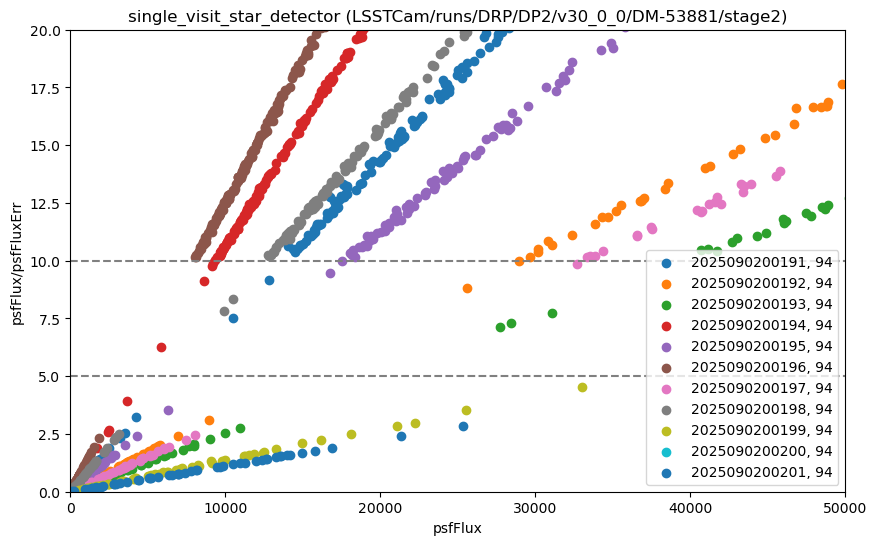

In [14]:
fig, ax = plt.subplots(1,1, figsize=(10,6),sharey=True)
for i,src in enumerate(dp2_catalogs):
    ax.scatter(src['psfFlux'], src['psfFlux']/src['psfFluxErr'], label=f"{np.unique(src['visit'])[0]}, {DETECTOR}")
    if i > 10: break

plt.legend()
ax.set_ylabel('psfFlux/psfFluxErr')
ax.set_xlabel('psfFlux')
ax.set_ylim(0,20); ax.set_xlim(0,50000)
ax.axhline(10,ls='--',color='gray')
ax.axhline(5,ls='--',color='gray')
plt.title(f"{datasetType} ({collection})")

/opt/lsst/software/stack/conda/envs/lsst-scipipe-12.1.0-exact/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:4859: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedColumn.
  arr.partition(


19.76710464211378 19.00960095025404


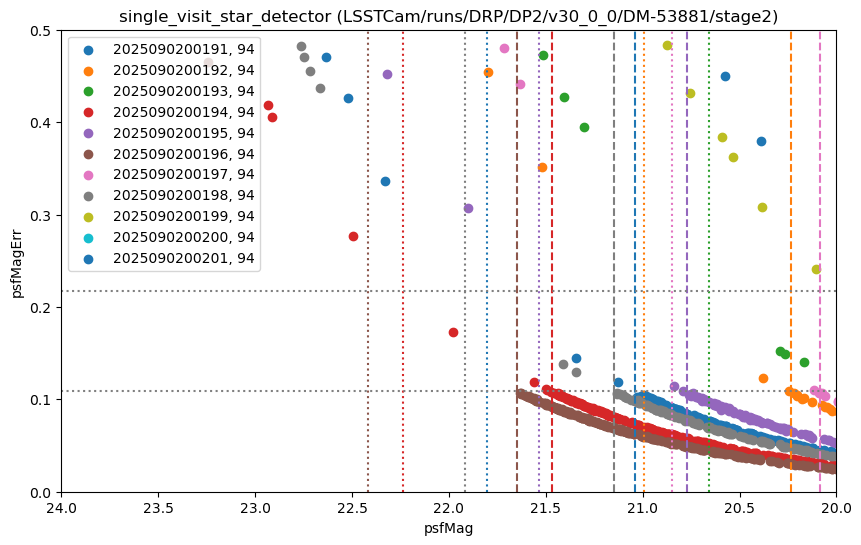

In [15]:
fig, ax = plt.subplots(1,1, figsize=(10,6),sharey=True)
for i, src in enumerate(dp2_catalogs):
    lines = ax.scatter(src['psfMag'], src['psfMagErr'], label=f"{np.unique(src['visit'])[0]}, {DETECTOR}")
    
    m10 = calculate_depth(src['ra'], src['dec'], src['psfMag'], src['psfMagErr'], snr=10.0)
    ax.axvline(m10, ls='--',color=lines.get_fc())
    m5 = calculate_depth(src['ra'], src['dec'], src['psfMag'], src['psfMagErr'], snr=5.0)
    ax.axvline(m5, ls=':',color=lines.get_fc())
    if i > 10: break
        
plt.legend()
ax.axhline(0.2171, ls=':', color='gray')
ax.axhline(0.1085, ls=':', color='gray')
ax.set_ylabel('psfMagErr')
ax.set_xlabel('psfMag')
ax.set_ylim(0,0.5); ax.set_xlim(24,20)
plt.title(f"{datasetType} ({collection})")
print(m5,m10)

(-0.2, 0.0)

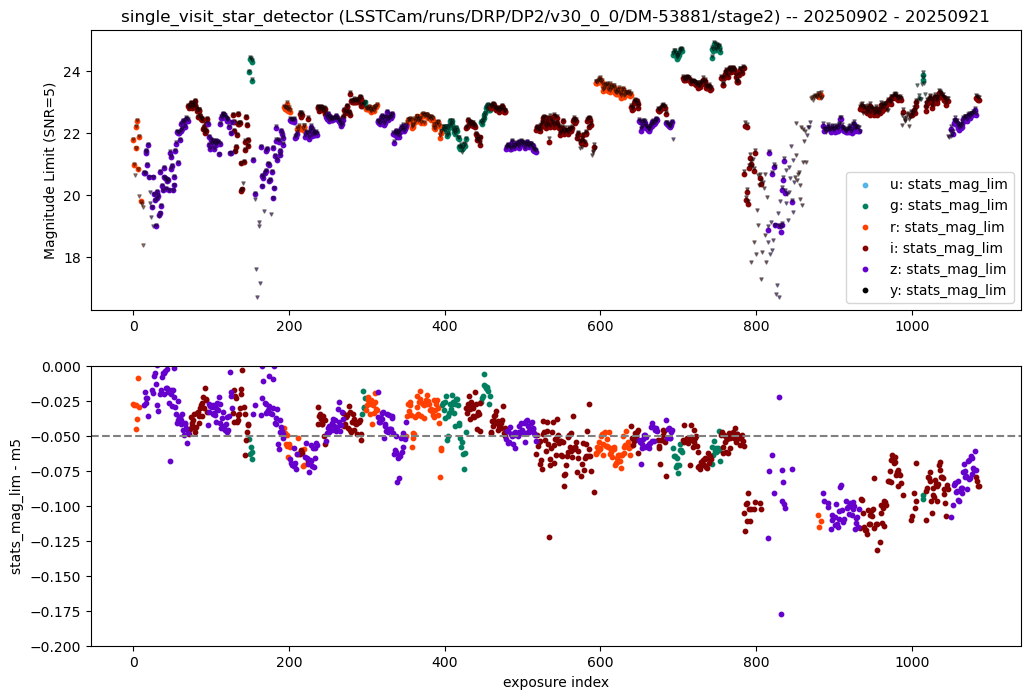

In [16]:
df = dp2_merge
fig,ax = plt.subplots(2,1, figsize=(12,8))

df['diff'] = df['stats_mag_lim'] - df['m5']
for b in ['u','g','r','i','z','y']:
    sel = df['band'] == b
    color = BAND_COLORS[b]
    ax[0].scatter(df[sel].index, df[sel]['stats_mag_lim'], c=color, s=10, label=f'{b}: stats_mag_lim')
    ax[0].scatter(df[sel].index, df[sel]['m5'], c=color, marker='v', ec='k', s=5, alpha=0.5)

    ax[1].scatter(df[sel].index, df[sel]['diff'], s=10, c=color)

median_diff = np.nanmedian(df['diff'])
ax[1].axhline(median_diff, ls='--', color='gray', label=f'Median: {median_diff:.2f}')

title = f"{datasetType} ({collection})"
title += f" -- {df['day_obs'].min()} - {df['day_obs'].max()}"
ax[0].set_title(title)
ax[0].legend()
ax[0].set_ylabel('Magnitude Limit (SNR=5)')
ax[1].set_ylabel('stats_mag_lim - m5')
ax[1].set_xlabel('exposure index')
ax[1].set_ylim(-0.2,0)

#### Sources from Nightly Validation

Looking at source detection threshold and depth using nightlyValidation processing (is this what is used for Rapid Analysis?). We are looking for the catalogs that were used to calculate `stats_mag_lim`. Based on prior knowledge, we are looking in `repo='main'` for collections like `*nightlyValidation*`. 

In [17]:
repo = "main"
collection = "LSSTCam/runs/nightlyValidation"
butler = dafButler.Butler(repo, collections=collection)
#where = "instrument='LSSTCam' and day_obs in (20250809) "
where = f"instrument='LSSTCam' and day_obs >= {DAY_OBS_MIN} and day_obs <= {DAY_OBS_MAX} "

# Single detector catalogs
where += f" and detector={DETECTOR}" 

# Probably the lowest level catalog. Returns SourceCatalog that must be converted using asAstropy
datasetType = 'single_visit_star_detector'

refs = butler.query_datasets(datasetType, where=where) 
print(len(refs))

2291


In [18]:
nv_results,nv_catalogs = [],[]
for i, ref in enumerate(refs):
    dataId = ref.dataId
    src = butler.get(ref)
    # Needed for single_visit_star_footprints
    if datasetType in ('single_visit_star_footprints'):
        src = src.asAstropy()
        src['psfFlux'] = src['base_PsfFlux_flux']
        src['psfFluxErr'] = src['base_PsfFlux_fluxErr']
        src['visit'] = ref.dataId['visit']
        
    src['psfMag'], src['psfMagErr'] = flux2mag(src['psfFlux'], src['psfFluxErr'])
    m5 = calculate_depth(src['ra'], src['dec'], src['psfMag'], src['psfMagErr'], snr=5.0)
    row = dict(visit=dataId['visit'], detector=dataId['detector'], day_obs=ref.dataId['day_obs'])
    row['seq_num'] = dataId['visit'] - ref.dataId['day_obs']*1e5
    row['m5'] = m5
    nv_results.append(row)
    if i <= 10: 
        nv_catalogs.append( src )

nv_results = pd.DataFrame(nv_results)
df = nv_merge = pd.merge(tab.to_pandas(), nv_results, on=['visit','detector'])
print( len(nv_results) )
print( len(nv_merge) ) 
df

2291
2286


,visit,detector,band,exp_midpt_mjd,stats_mag_lim,day_obs,seq_num,m5
0,2025090200007,94,r,60921.071360,22.923059,20250902,7.0,22.956073
1,2025090200009,94,r,60921.072377,23.229029,20250902,9.0,23.258686
2,2025090200010,94,r,60921.072797,23.199659,20250902,10.0,23.225663
3,2025090200011,94,r,60921.073368,23.154774,20250902,11.0,23.182111
4,2025090200012,94,r,60921.073788,22.971628,20250902,12.0,23.009161
...,...,...,...,...,...,...,...,...
2281,2025092000164,94,z,60939.202222,None,20250920,164.0,22.265425
2282,2025092000165,94,z,60939.202966,22.196999,20250920,165.0,22.285945
2283,2025092000166,94,z,60939.203387,22.446295,20250920,166.0,22.517795
2284,2025092000167,94,z,60939.204265,None,20250920,167.0,22.267480


Text(0.5, 1.0, 'single_visit_star_detector (LSSTCam/runs/nightlyValidation)')

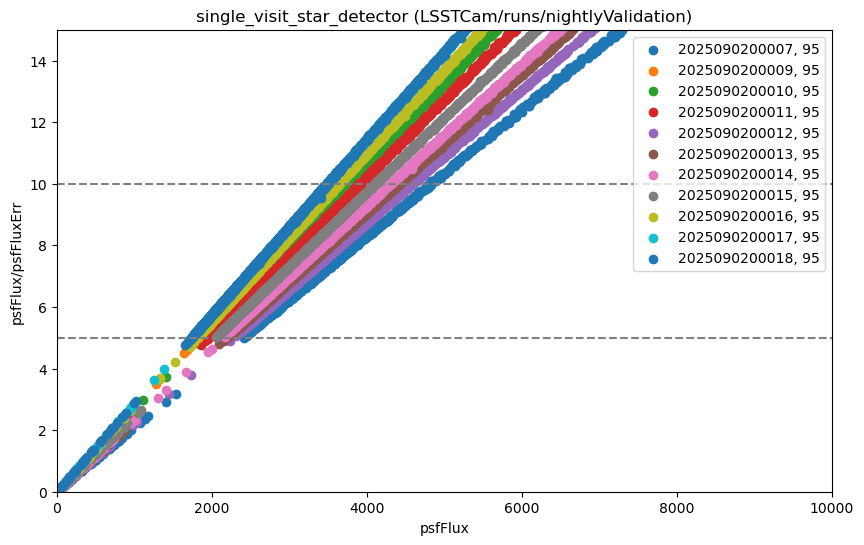

In [19]:
fig, ax = plt.subplots(1,1, figsize=(10,6),sharey=True)
for i,src in enumerate(nv_catalogs):
    ax.scatter(src['psfFlux'], src['psfFlux']/src['psfFluxErr'], label=f"{np.unique(src['visit'])[0]}, 95")
    if i > 10: break

plt.legend() 
ax.set_ylabel('psfFlux/psfFluxErr')
ax.set_xlabel('psfFlux')
ax.set_ylim(0,15); ax.set_xlim(0,10000)
ax.axhline(10,ls='--',color='gray')
ax.axhline(5,ls='--',color='gray')

plt.title(f"{datasetType} ({collection})")

Text(0.5, 1.0, 'single_visit_star_detector (LSSTCam/runs/nightlyValidation)')

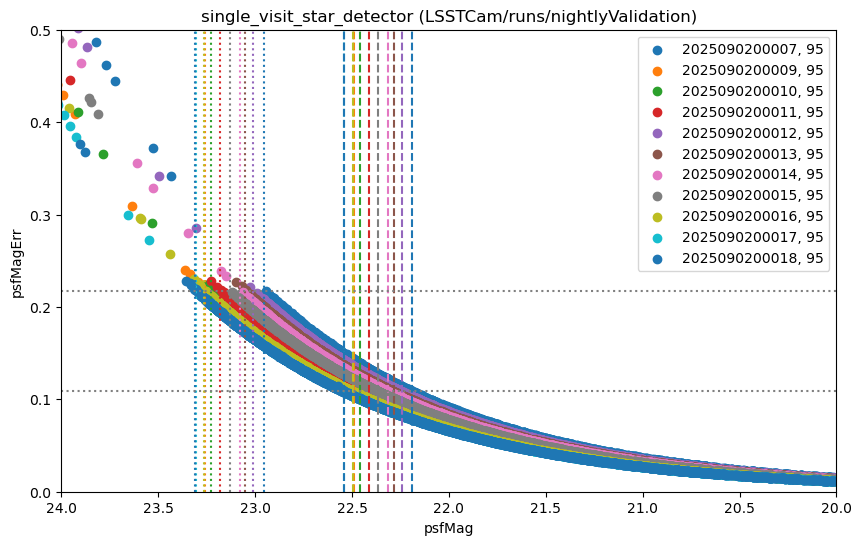

In [20]:
fig, ax = plt.subplots(1,1, figsize=(10,6),sharey=True)
for i,src in enumerate(nv_catalogs):
    lines = ax.scatter(src['psfMag'], src['psfMagErr'], label=f"{np.unique(src['visit'])[0]}, 95")
    
    m10 = calculate_depth(src['ra'], src['dec'], src['psfMag'], src['psfMagErr'], snr=10.0)
    ax.axvline(m10, ls='--',color=lines.get_fc())
    m5 = calculate_depth(src['ra'], src['dec'], src['psfMag'], src['psfMagErr'], snr=5.0)
    ax.axvline(m5, ls=':',color=lines.get_fc())
    if i > 10: break
        
plt.legend()
ax.axhline(0.2171, ls=':', color='gray')
ax.axhline(0.1085, ls=':', color='gray')
ax.set_ylabel('psfMagErr')
ax.set_xlabel('psfMag')
ax.set_ylim(0,0.5); ax.set_xlim(24,20)
plt.title(f"{datasetType} ({collection})")

(-0.2, 0.0)

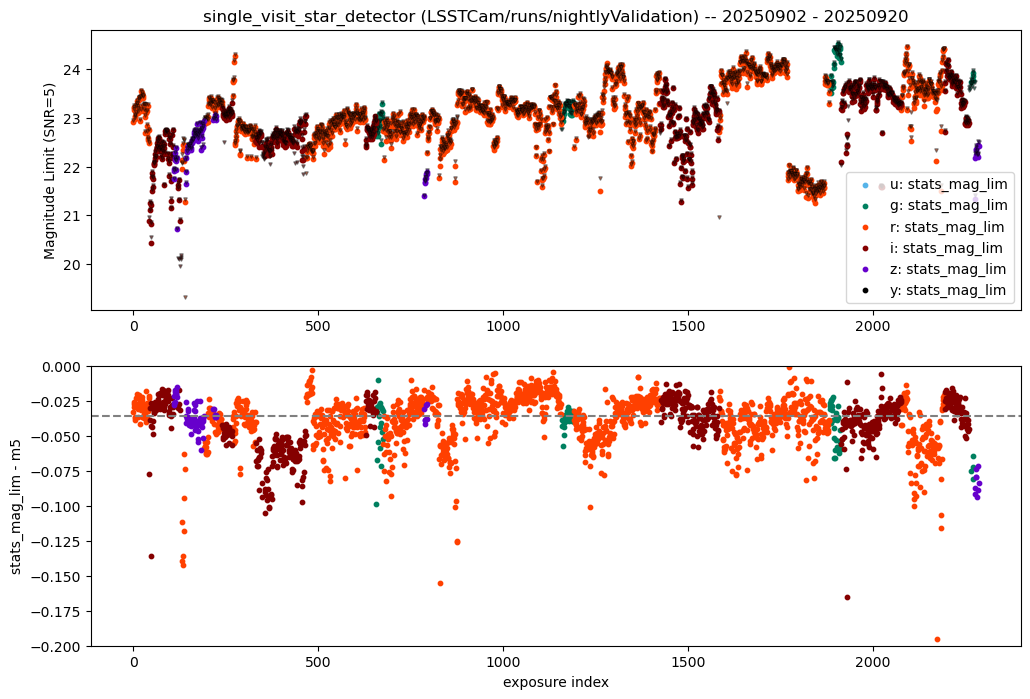

In [21]:
fig,ax = plt.subplots(2,1, figsize=(12,8))
df['diff'] = df['stats_mag_lim'] - df['m5']
for b in ['u','g','r','i','z','y']:
    sel = df['band'] == b
    color = BAND_COLORS[b]
    ax[0].scatter(df[sel].index, df[sel]['stats_mag_lim'], c=color, s=10, label=f'{b}: stats_mag_lim')
    ax[0].scatter(df[sel].index, df[sel]['m5'], c=color, marker='v', ec='k', s=5, alpha=0.5)

    ax[1].scatter(df[sel].index, df[sel]['diff'], c=color, s=10)

median_diff = np.nanmedian(df['diff'])
ax[1].axhline(median_diff, ls='--', color='gray', label=f'Median: {median_diff:.2f}')

title = f"{datasetType} ({collection})"
title += f" -- {df['day_obs'].min()} - {df['day_obs'].max()}"
ax[0].set_title(title)
ax[0].legend()
ax[0].set_ylabel('Magnitude Limit (SNR=5)')
ax[1].set_ylabel('stats_mag_lim - m5')
ax[1].set_xlabel('exposure index')
ax[1].set_ylim(-0.2,0)